# Which diabetes indicators justify a higher premium? (XGBoost only)
Clean final notebook. One chart per claim in the business answer. Data: BRFSS 2015 (253,680 respondents). Y = prediabetes or diabetes (15.8%).

**Answer:** high blood pressure, high cholesterol, obesity and age justify a higher premium most. A short questionnaire can tier applicants but cannot diagnose them.

## Plain-English glossary
| Term | Meaning |
|---|---|
| **Y / "at risk"** | The thing we predict: whether a respondent has **diabetes or prediabetes** (about 16% of people). |
| **Indicator / question** | One survey answer, e.g. high blood pressure, BMI, age. |
| **Rate (%)** | Out of 100 people in a group, how many have diabetes/prediabetes. |
| **Correlation** | A number from -1 to +1 showing how consistently two things move together. It shows association, **not** cause. |
| **Model** | A formula learned from past survey answers that gives each person a **risk score** between 0 and 1. |
| **Training / validation / test data** | Training = data the model learns from. Validation = used to tune settings. Test = data the model has never seen, used for the honest final grade. |
| **AUC (ROC-AUC)** | How well the model ranks risky people above safe ones. 0.5 = coin flip, 1.0 = perfect. ~0.82 here = decent, not perfect. |
| **PR-AUC** | Like AUC but stricter when the group we look for is rare. Random guessing scores about 0.16 (the share of at-risk people). |
| **Recall** | Of all people who really have diabetes, the share the model catches. |
| **Precision** | Of all people the model flags as high-risk, the share who really have diabetes. |
| **Threshold** | The cut-off score above which we call someone "high risk". Lower it: catch more diabetics but more false alarms. |
| **Imbalance** | Only ~16% of people are at risk, so a model saying "nobody has diabetes" is 84% accurate yet useless. We therefore don't judge on accuracy. |
| **Class weights / SMOTE** | Two ways to stop the model ignoring the rare group: weights make mistakes on at-risk people count more; SMOTE creates synthetic extra at-risk examples (training data only). |
| **Calibration** | Whether a predicted 20% risk really means about 20 in 100 people get diabetes. Needed before a score can set a price. |
| **Feature importance** | How much the model's accuracy drops if one question is scrambled. Big drop = the model relies on it. |


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from xgboost import XGBClassifier
sns.set_theme(style='whitegrid'); SEED=0; BASE='#4c78a8'; RED='#e45756'
raw = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
feats = [c for c in raw.columns if c!='Diabetes_012']
y = (raw.Diabetes_012>0).astype(int); X = raw[feats]; df = X.assign(y=y)
AGE = {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',11:'70-74',12:'75-79',13:'80+'}
print(X.shape, 'positive rate', y.mean().round(4))

(253680, 21) positive rate 0.1576


## 1. Indicators that justify a higher premium

### 1a. Medical indicators: diabetes rate with vs without

> **How to read the chart below**
>
> Each row is a yes/no question. The **grey bar** is the **% of people who have diabetes or prediabetes among those who answered 'no'**; the **red bar** is the same percentage among those who answered **'yes'**. The label at the end (e.g. *3.8x*) is red divided by grey: how many times *more likely* the 'yes' group is. The **dashed line** is the overall average (15.8%).
> - Example: of people **without** high blood pressure, about 7 in 100 have diabetes; of people **with** it, about 27 in 100: **3.8 times** as likely.
> - A red bar *shorter* than grey (physical activity, 0.6x) means *protective*.
>
> Each row is a separate comparison and the same person can appear in several rows, so do not add rows together.

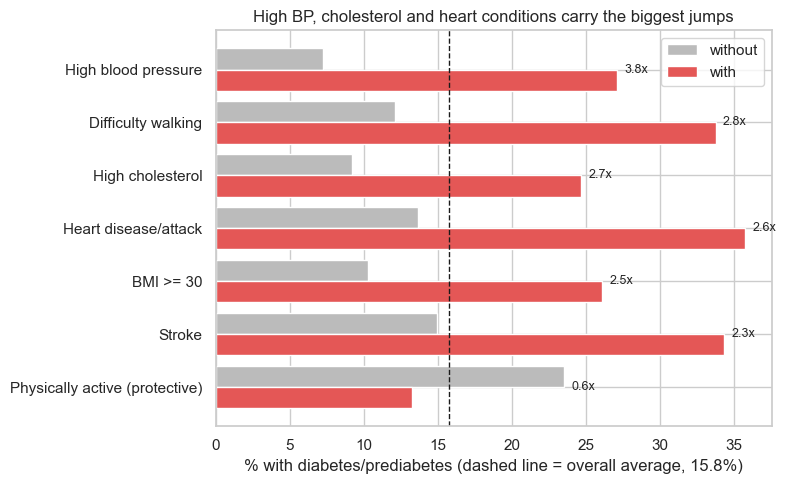

                                without  with  ratio
Physically active (protective)     23.6  13.2    0.6
Stroke                             15.0  34.3    2.3
BMI >= 30                          10.3  26.1    2.5
Heart disease/attack               13.7  35.8    2.6
High cholesterol                    9.2  24.7    2.7
Difficulty walking                 12.1  33.8    2.8
High blood pressure                 7.2  27.1    3.8


In [2]:
ind = {'High blood pressure':df.HighBP==1,'High cholesterol':df.HighChol==1,'BMI >= 30':df.BMI>=30,'Heart disease/attack':df.HeartDiseaseorAttack==1,
       'Stroke':df.Stroke==1,'Difficulty walking':df.DiffWalk==1,'Physically active (protective)':df.PhysActivity==1}
t = pd.DataFrame({k:{'without':df.y[~m].mean()*100,'with':df.y[m].mean()*100} for k,m in ind.items()}).T
t['ratio'] = t['with']/t['without']; t = t.sort_values('ratio')
fig, ax = plt.subplots(figsize=(8,5)); i = np.arange(len(t))
ax.barh(i+.2, t['without'], .4, color='#bbbbbb', label='without'); ax.barh(i-.2, t['with'], .4, color=RED, label='with')
for j,(a,b,r) in enumerate(zip(t['without'],t['with'],t['ratio'])): ax.text(max(a,b)+.5, j, f'{r:.1f}x', va='center', fontsize=9)
ax.set_yticks(i); ax.set_yticklabels(t.index); ax.axvline(df.y.mean()*100, c='k', ls='--', lw=1); ax.set_xlabel('% with diabetes/prediabetes (dashed line = overall average, 15.8%)')
ax.set_title('High BP, cholesterol and heart conditions carry the biggest jumps'); ax.legend(); plt.tight_layout(); plt.show()
print(t.round(1))

**Conclusion:** High blood pressure (3.8x), difficulty walking, high cholesterol and heart disease/stroke are the biggest risk jumps; physical activity is protective.

### 1b. BMI and age: risk rises non-linearly

> **How to read the chart below**
>
> **Left:** people are grouped by BMI (a weight-for-height measure; 25-30 is overweight, over 30 is obese). Each bar is the **% in that group with diabetes/prediabetes**. **Right:** the same % for each **age group** (18-24 up to 80+).
> **What to notice:** BMI risk stays low until 25 and then climbs; age risk climbs steadily and peaks around 70-79.

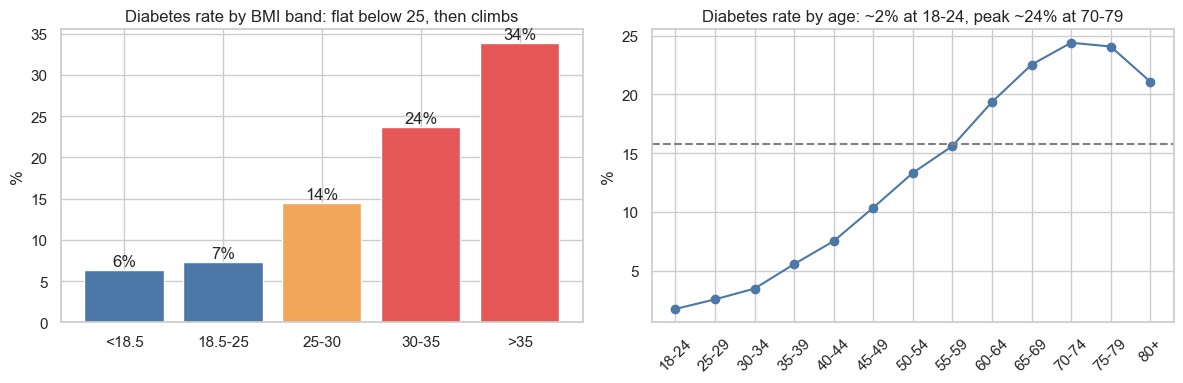

In [3]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
bm = df.groupby(pd.cut(df.BMI,[0,18.5,25,30,35,100],labels=['<18.5','18.5-25','25-30','30-35','>35']), observed=True).y.mean()*100
ax[0].bar(bm.index.astype(str), bm.values, color=[BASE,BASE,'#f2a65a',RED,RED]); ax[0].set_title('Diabetes rate by BMI band: flat below 25, then climbs'); ax[0].set_ylabel('%')
for k,v in enumerate(bm.values): ax[0].text(k, v+.5, f'{v:.0f}%', ha='center')
ag = df.groupby('Age').y.mean()*100
ax[1].plot([AGE[k] for k in ag.index], ag.values, marker='o', color=BASE); ax[1].set_title('Diabetes rate by age: ~2% at 18-24, peak ~24% at 70-79'); ax[1].tick_params(axis='x', rotation=45); ax[1].set_ylabel('%')
ax[1].axhline(df.y.mean()*100, c='grey', ls='--'); plt.tight_layout(); plt.show()

**Conclusion:** BMI risk is low and flat below 25, then climbs about 7-10 points per band (7% to 34%). Age risk climbs from about 2% to about 24%, easing after 80. Age is strong, but age-based pricing is often regulated.

### 1c. Risk flags compound

> **How to read the chart below**
>
> We give each person up to **6 risk flags**: high blood pressure, high cholesterol, BMI of 30+, heart disease/attack, difficulty walking, not physically active.
> **Left:** the **% with diabetes** for people with 0, 1 ... 6 flags. **Right:** if we flag everyone with **at least k flags**, three bars per cut-off: the **share of all people flagged (grey)**, the **share of all diabetics caught (blue)** and **precision, the share of flagged people who really have diabetes (red)**.
> **What to notice:** more flags means higher risk, but a stricter cut-off catches fewer diabetics, so there is a trade-off between catching more and being right more often.

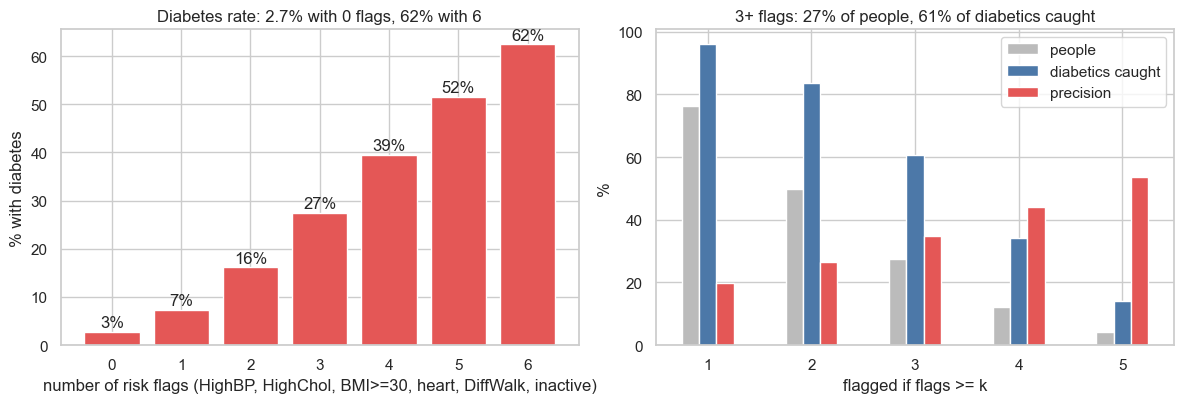

   people  diabetics caught  precision
1    76.2              95.9       19.8
2    49.9              83.7       26.4
3    27.3              60.6       34.9
4    12.2              34.2       44.2
5     4.1              14.1       53.5


In [4]:
df['nflags'] = df.HighBP+df.HighChol+(df.BMI>=30).astype(int)+df.HeartDiseaseorAttack+df.DiffWalk+(1-df.PhysActivity)
f = df.groupby('nflags').y.agg(['mean','size']); f['mean']*=100
cov = pd.DataFrame({k:{'people':(df.nflags>=k).mean()*100,'diabetics caught':df.y[df.nflags>=k].sum()/df.y.sum()*100,'precision':df.y[df.nflags>=k].mean()*100} for k in range(1,6)}).T
fig, ax = plt.subplots(1,2, figsize=(12,4.2))
ax[0].bar(f.index.astype(int), f['mean'], color=RED); ax[0].set_xlabel('number of risk flags (HighBP, HighChol, BMI>=30, heart, DiffWalk, inactive)'); ax[0].set_ylabel('% with diabetes'); ax[0].set_title('Diabetes rate: 2.7% with 0 flags, 62% with 6')
for k,v in zip(f.index, f['mean']): ax[0].text(k, v+1, f'{v:.0f}%', ha='center')
cov[['people','diabetics caught','precision']].plot.bar(ax=ax[1], rot=0, color=['#bbbbbb',BASE,RED]); ax[1].set_xlabel('flagged if flags >= k'); ax[1].set_ylabel('%'); ax[1].set_title('3+ flags: 27% of people, 61% of diabetics caught')
plt.tight_layout(); plt.show(); print(cov.round(1))

**Conclusion:** Risk compounds steeply with the number of flags. Flagging 3 or more covers 27% of people and catches 61% of diabetics, but only 35% of those flagged have diabetes. Raising the bar to 5 flags raises precision to 54% but catches only 14% of diabetics.

## 2. Strong predictors you should not price on directly

> **How to read the chart below**
>
> Three checks on predictors we may not want to price on.
> **Left, income heatmap:** each cell is the % with diabetes for a BMI band (rows) and income band (columns); darker = higher. Within every row, lower income is still higher risk, so income is not just a stand-in for weight (the gap also holds within every age group: 40-59 is 26% for low vs 8% for high income).
> **Middle, alcohol:** % with diabetes for non-heavy (blue) vs heavy drinkers (orange) within each age group. Heavy drinkers are *lower* almost everywhere, a puzzle we cannot explain, so no discount.
> **Right, general health:** % with diabetes by how people rate their own health. Risk rises sharply, but poor self-rated health is partly a *result* of being ill, so it is a symptom as much as a cause.

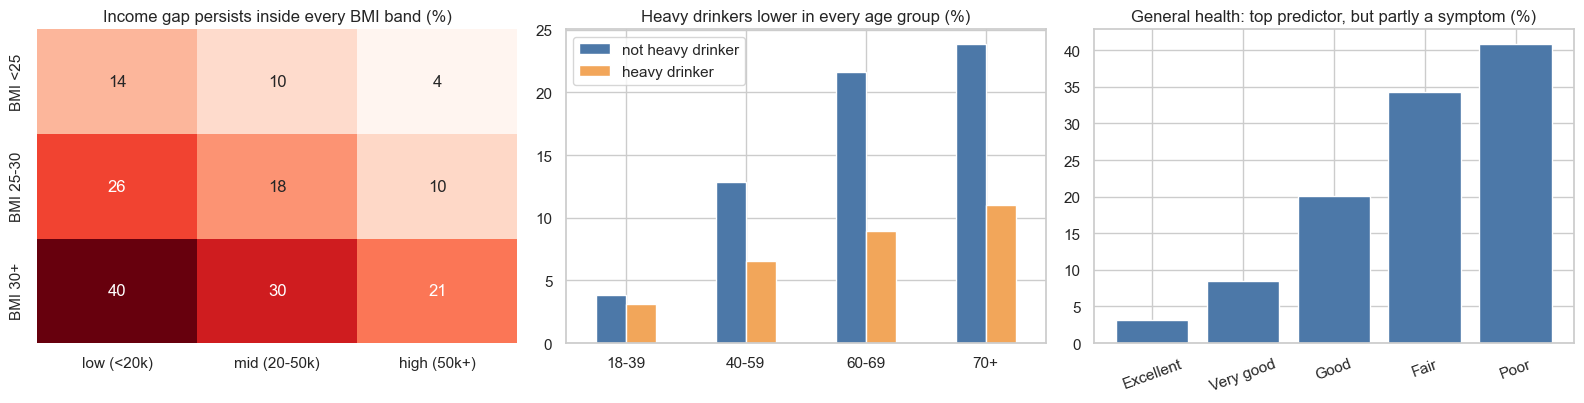

In [5]:
df['IncGrp'] = pd.cut(df.Income,[0,3,6,8],labels=['low (<20k)','mid (20-50k)','high (50k+)']); df['BMIb'] = pd.cut(df.BMI,[0,25,30,100],labels=['BMI <25','BMI 25-30','BMI 30+'])
df['AgeGrp'] = pd.cut(df.Age,[0,4,8,10,13],labels=['18-39','40-59','60-69','70+'])
fig, ax = plt.subplots(1,3, figsize=(16,4.2))
h = df.pivot_table(index='BMIb', columns='IncGrp', values='y', aggfunc='mean', observed=True)*100
sns.heatmap(h, annot=True, fmt='.0f', cmap='Reds', ax=ax[0], cbar=False); ax[0].set_title('Income gap persists inside every BMI band (%)'); ax[0].set_ylabel(''); ax[0].set_xlabel('')
a = df.pivot_table(index='AgeGrp', columns='HvyAlcoholConsump', values='y', aggfunc='mean', observed=True)*100
a.columns=['not heavy drinker','heavy drinker']; a.plot.bar(ax=ax[1], rot=0, color=[BASE,'#f2a65a']); ax[1].set_title('Heavy drinkers lower in every age group (%)'); ax[1].set_xlabel('')
g = df.groupby('GenHlth').y.mean()*100; ax[2].bar(['Excellent','Very good','Good','Fair','Poor'], g.values, color=BASE); ax[2].set_title('General health: top predictor, but partly a symptom (%)'); ax[2].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**Conclusion:** Income gaps persist inside every BMI band (BMI 30+: 40% low income vs 21% high) and within every age group, so it is not only a medical or age proxy, but pricing on it penalises poorer people (fairness/regulatory risk). Heavy drinkers show lower rates in every age group (small at 18-39), unexplained (they also report better health, but the gap holds within each health level), so do not give a discount. General health rises steeply from 3% to 41%, but it partly reflects illness already present.

## 3. What the model can do (XGBoost + class weights)
Split **by answer profile** (identical respondents never in two splits): train 60% / validation 15% / test 25%.

> **How to read the chart below**
>
> We split people so that **identical answer profiles never appear in both training and test data**, then trained XGBoost (the model) and graded it on the unseen test data.
> **Left, ROC curve:** as we flag more people from the highest score down, how many real diabetics we catch (up) against how many healthy people we wrongly flag (right). Dashed diagonal = random guessing; **AUC** (area under the curve) 0.5 = coin flip, 1.0 = perfect.
> **Right, Precision-Recall curve:** *recall* = share of diabetics caught; *precision* = share of flagged people who really have diabetes; dashed = random (about 16%).
> **What to notice:** clearly better than guessing, but not perfect: moderate predictive power.

no shared answer profiles between splits (asserted). rows: 152497 37980 63203
Test ROC-AUC 0.824 | PR-AUC 0.455 | base rate 0.156


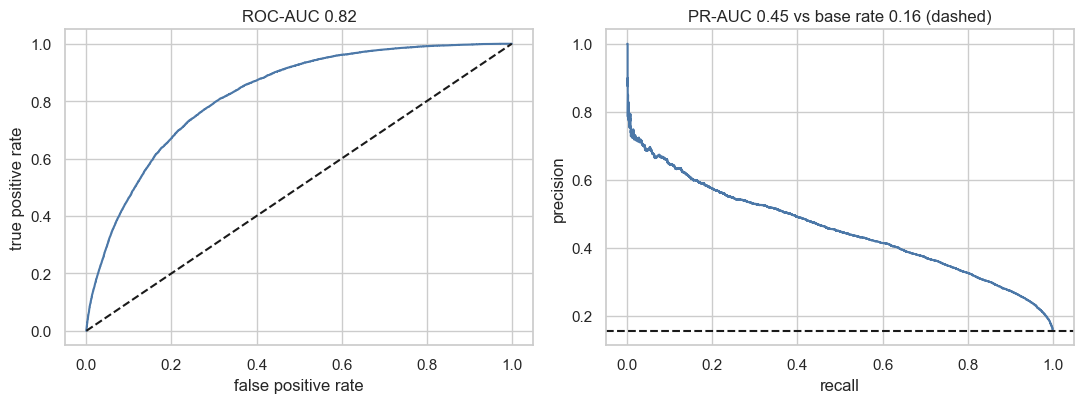

In [6]:
grp = raw.groupby(feats).ngroup()
def gsplit(idx, k):
    a,b = next(StratifiedGroupKFold(k, shuffle=True, random_state=SEED).split(idx, y[idx], grp[idx])); return idx[a], idx[b]
tv, te = gsplit(np.arange(len(raw)), 4); tr, va = gsplit(tv, 5)
g = lambda i: set(grp.iloc[i]); assert not (g(tr)&g(te)) and not (g(va)&g(te)) and not (g(tr)&g(va))
Xtr,ytr,Xva,yva,Xte,yte = X.iloc[tr],y.iloc[tr],X.iloc[va],y.iloc[va],X.iloc[te],y.iloc[te]
spw = (ytr==0).sum()/(ytr==1).sum()
mk = lambda: XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw, eval_metric='logloss', n_jobs=-1, random_state=SEED)
xgb = mk().fit(Xtr, ytr); pva, pte = xgb.predict_proba(Xva)[:,1], xgb.predict_proba(Xte)[:,1]
print('no shared answer profiles between splits (asserted). rows:', len(tr), len(va), len(te))
print('Test ROC-AUC %.3f | PR-AUC %.3f | base rate %.3f' % (roc_auc_score(yte,pte), average_precision_score(yte,pte), yte.mean()))
fig, ax = plt.subplots(1,2, figsize=(11,4.2))
fp,tp,_ = roc_curve(yte,pte); ax[0].plot(fp,tp,color=BASE); ax[0].plot([0,1],[0,1],'k--'); ax[0].set(title='ROC-AUC %.2f' % roc_auc_score(yte,pte), xlabel='false positive rate', ylabel='true positive rate')
pr,rc,_ = precision_recall_curve(yte,pte); ax[1].plot(rc,pr,color=BASE); ax[1].axhline(yte.mean(), c='k', ls='--'); ax[1].set(title='PR-AUC %.2f vs base rate %.2f (dashed)' % (average_precision_score(yte,pte), yte.mean()), xlabel='recall', ylabel='precision')
plt.tight_layout(); plt.show()

**Conclusion:** AUC 0.82 is well above chance, but precision falls quickly as recall rises: survey answers give moderate predictive power.

### 3a. Short form: five questions are enough

> **How to read the chart below**
>
> **Left, importance:** we scramble one question's answers and see how much the model's accuracy falls; **longer bar = the model relies on it more**.
> **Middle:** accuracy (AUC, vertical) when the model may only use its top **k questions** (horizontal). The line flattens after about 5 questions.
> **Right:** three questionnaires side by side. Taller = more accurate. The 4-question form (red) is clearly weaker than adding general health (blue), which gets close to using all questions (grey).
> **What to notice:** 5 questions capture nearly all of the signal.

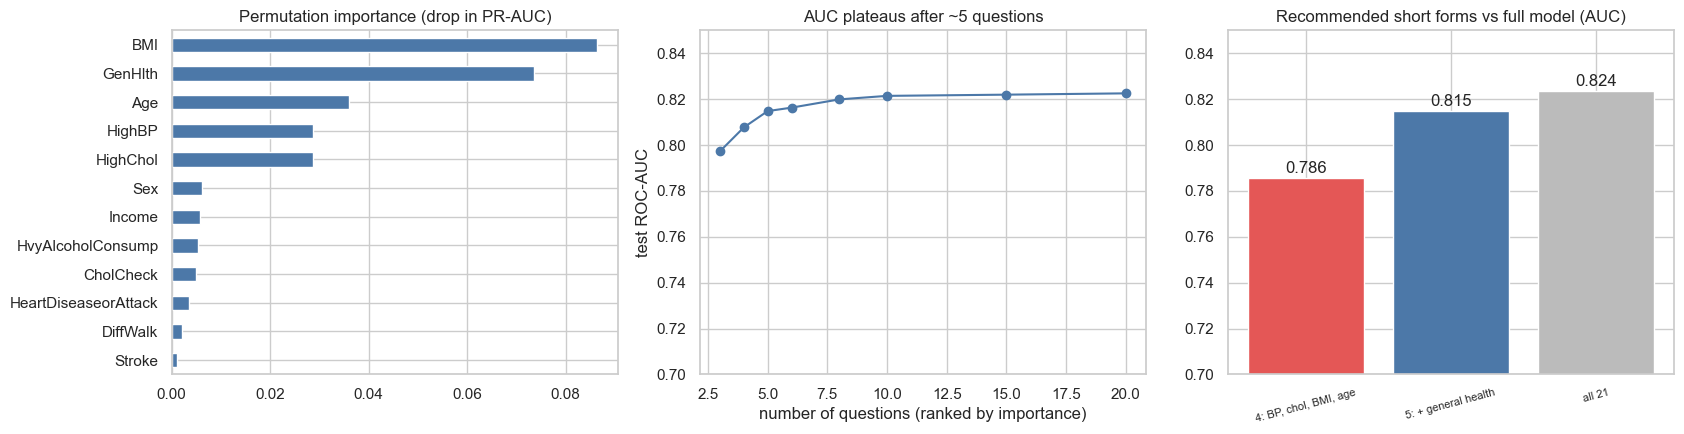

{'4: BP, chol, BMI, age': 0.786, '5: + general health': 0.815, 'all 21': 0.824}
top ranked (excl. CholCheck): ['BMI', 'GenHlth', 'Age', 'HighBP', 'HighChol', 'Sex', 'Income', 'HvyAlcoholConsump']


In [7]:
# rank on VALIDATION data so the test set stays untouched for the short-form check
imp = pd.Series(permutation_importance(xgb, Xva, yva, scoring='average_precision', n_repeats=5, random_state=SEED, n_jobs=-1).importances_mean, feats).sort_values()
order = [f for f in imp.index[::-1] if f!='CholCheck']   # CholCheck = artefact (never checked -> no diagnosis)
rows = []
for k in [3,4,5,6,8,10,15,20]:
    c = order[:k]; p = mk().fit(Xtr[c],ytr).predict_proba(Xte[c])[:,1]; rows.append((k, roc_auc_score(yte,p), ', '.join(c[-1:])))
sf = pd.DataFrame(rows, columns=['n','AUC','added'])
forms = {'4: BP, chol, BMI, age':['HighBP','HighChol','BMI','Age'], '5: + general health':['HighBP','HighChol','BMI','Age','GenHlth'], f'all {len(feats)}':feats}
fa = {k:roc_auc_score(yte, mk().fit(Xtr[c],ytr).predict_proba(Xte[c])[:,1]) for k,c in forms.items()}
fig, ax = plt.subplots(1,3, figsize=(17,4.5))
imp.tail(12).plot.barh(ax=ax[0], color=BASE); ax[0].set_title('Permutation importance (drop in PR-AUC)')
ax[1].plot(sf.n, sf.AUC, marker='o', color=BASE); ax[1].set_xlabel('number of questions (ranked by importance)'); ax[1].set_ylabel('test ROC-AUC'); ax[1].set_title('AUC plateaus after ~5 questions'); ax[1].set_ylim(0.7,0.85)
ax[2].bar(range(len(fa)), fa.values(), color=[RED,BASE,'#bbbbbb']); ax[2].set_xticks(range(len(fa))); ax[2].set_xticklabels(list(fa), rotation=15, fontsize=8); ax[2].set_ylim(0.7,0.85); ax[2].set_title('Recommended short forms vs full model (AUC)')
for k,v in enumerate(fa.values()): ax[2].text(k, v+.002, f'{v:.3f}', ha='center')
plt.tight_layout(); plt.show(); print({k:round(v,3) for k,v in fa.items()}); print('top ranked (excl. CholCheck):', order[:8])

**Conclusion:** Importance is led by BMI, general health, age, cholesterol and blood pressure; sex, income and the lifestyle questions add little once these five are known (sex and income rank 6th and 7th, but with small importance). Heart disease, stroke and difficulty walking have high univariate ratios but add almost nothing here, because BMI, age, BP and general health already carry their signal. These top 5 questions reach AUC 0.815 vs 0.824 for all 21 features, so a short form works. Dropping general health costs more (0.786), so the 4-question form BP/cholesterol/BMI/age is noticeably weaker; general health is worth keeping despite being partly a symptom.

### 3b. Operating point: catches most diabetics, but most flagged are healthy
Assumed cost: missing a diabetic costs 5x a false alarm. Threshold chosen on the validation set only.

> **How to read the chart below**
>
> The model gives each person a risk score; we flag people whose score passes a **threshold**. We *assume* missing a diabetic costs 5 and a false alarm costs 1.
> **Left:** total cost on the validation data at each threshold; the **red dashed line** is the cheapest.
> **Middle:** the test people split into **flagged high-risk** and **not flagged**; red = really has diabetes, grey = healthy. The flagged bar is about one-third red: **two out of three flagged people are healthy**. The red sliver in 'not flagged' is the diabetics we miss.
> **Right:** total assumed cost if we treat everyone as low-risk vs using the model.

threshold 0.49 | recall 79.8% | precision 32.7% | cost 26178 vs 49390 if nobody is flagged


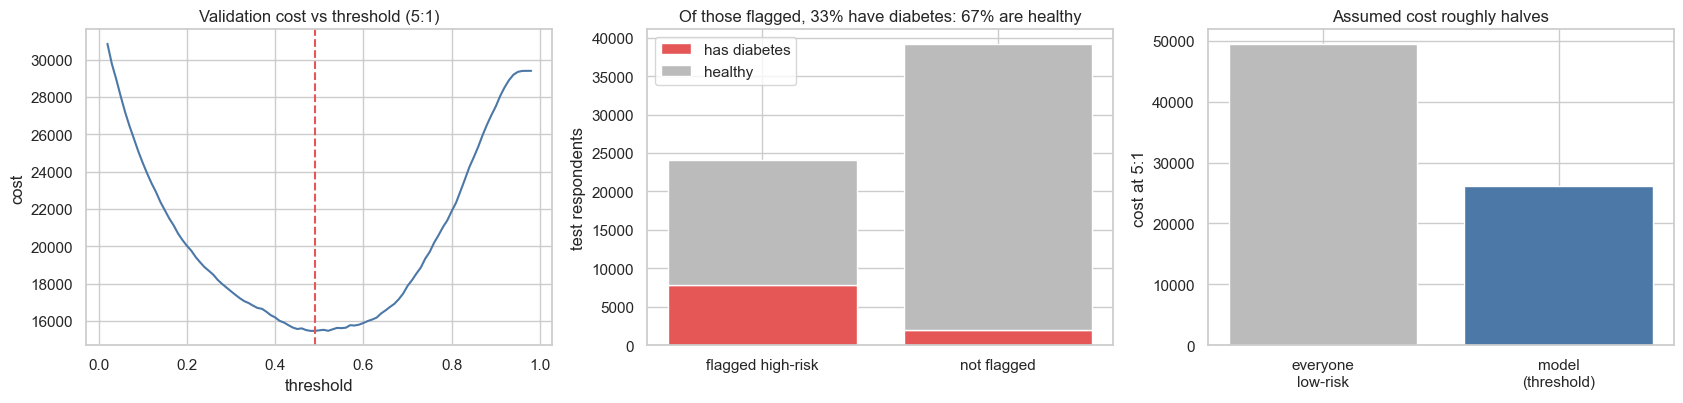

In [8]:
COST_FN, COST_FP = 5, 1
ths = np.linspace(0.02, 0.98, 97)
cost = lambda p,yy,t: COST_FN*((p<t)&(yy==1)).sum()+COST_FP*((p>=t)&(yy==0)).sum()
t_star = ths[int(np.argmin([cost(pva,yva,t) for t in ths]))]
fl = pte>=t_star; tp, fp_, fn = (fl&(yte==1)).sum(), (fl&(yte==0)).sum(), ((~fl)&(yte==1)).sum()
prec, rec = tp/fl.sum(), tp/yte.sum()
print('threshold %.2f | recall %.1f%% | precision %.1f%% | cost %d vs %d if nobody is flagged' % (t_star, rec*100, prec*100, cost(pte,yte,t_star), COST_FN*yte.sum()))
fig, ax = plt.subplots(1,3, figsize=(17,4.2))
ax[0].plot(ths, [cost(pva,yva,t) for t in ths], color=BASE); ax[0].axvline(t_star, c=RED, ls='--'); ax[0].set(title='Validation cost vs threshold (5:1)', xlabel='threshold', ylabel='cost')
ax[1].bar(['flagged high-risk'], [tp], color=RED, label='has diabetes'); ax[1].bar(['flagged high-risk'], [fp_], bottom=[tp], color='#bbbbbb', label='healthy')
ax[1].bar(['not flagged'], [fn], color=RED); ax[1].bar(['not flagged'], [(~fl&(yte==0)).sum()], bottom=[fn], color='#bbbbbb')
ax[1].set_title(f'Of those flagged, {prec:.0%} have diabetes: {1-prec:.0%} are healthy'); ax[1].legend(); ax[1].set_ylabel('test respondents')
ax[2].bar(['everyone\nlow-risk','model\n(threshold)'], [COST_FN*yte.sum(), cost(pte,yte,t_star)], color=['#bbbbbb',BASE]); ax[2].set_title('Assumed cost roughly halves'); ax[2].set_ylabel('cost at 5:1')
plt.tight_layout(); plt.show()

**Conclusion:** At the 5:1 assumption the model catches about 80% of diabetics but only about a third of those flagged have diabetes (two thirds are healthy), so a flat loading on everyone flagged would overcharge most of them. It is a risk-tiering tool, not a diagnosis. The 5:1 ratio is an assumption; real claims data should set it.

### 3c. Calibrated risk tiers
Class-weighted scores over-predict risk, so we recalibrate (isotonic, fitted on validation) and cut tiers on the calibrated probability. Tier cut-offs (10% and 30%) are illustrative.

> **How to read the chart below**
>
> **Left, calibration:** people sorted into 10 groups by predicted risk. Horizontal = predicted risk, vertical = share who really had diabetes; the dashed diagonal = honest probabilities. The raw model (red) exaggerates risk; after recalibration (blue) it matches reality.
> **Middle:** we cut people into **Low (<10% risk), Medium (10-30%), High (30%+)** tiers and show the **actual diabetes rate in each**. Clear steps mean the tiers are meaningful.
> **Right:** for each tier, the **share of all people (grey)** against the **share of all diabetics (red)**. The High tier is about one-fifth of people but over half of diabetics.

mean predicted risk raw 0.389 | calibrated 0.155 | actual 0.156


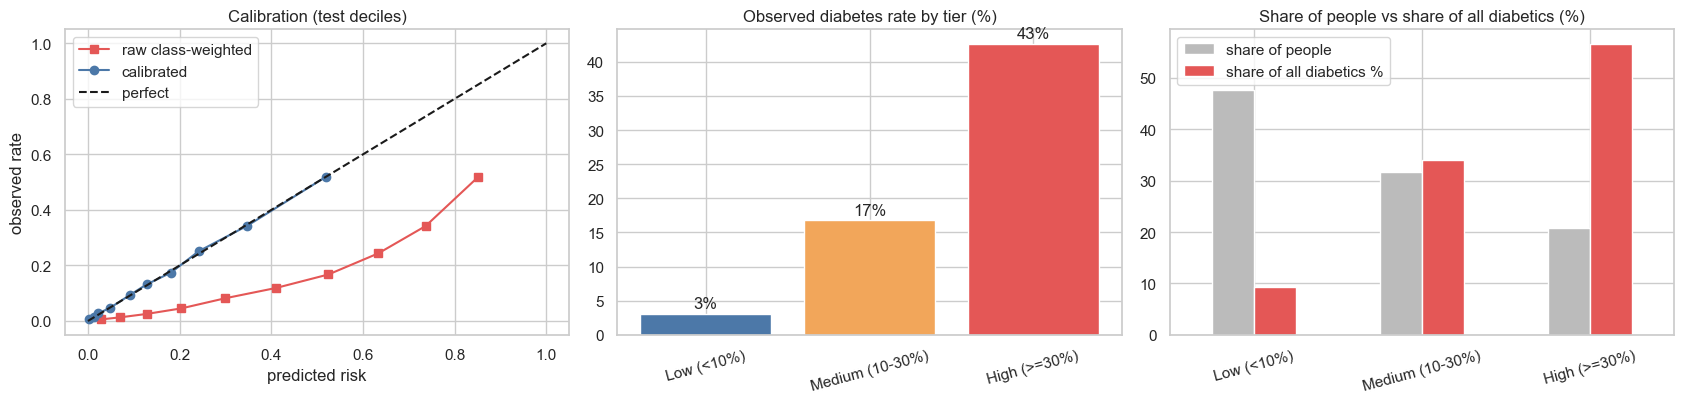

                  size  share of people  observed diabetes %  \
tier                                                           
Low (<10%)       30088             47.6                  3.1   
Medium (10-30%)  20002             31.6                 16.8   
High (>=30%)     13113             20.7                 42.6   

                 share of all diabetics %  
tier                                       
Low (<10%)                            9.4  
Medium (10-30%)                      34.1  
High (>=30%)                         56.6  


In [9]:
iso = IsotonicRegression(out_of_bounds='clip').fit(pva, yva); pc = iso.predict(pte)
print('mean predicted risk raw %.3f | calibrated %.3f | actual %.3f' % (pte.mean(), pc.mean(), yte.mean()))
tier = pd.cut(pc, [-1,0.10,0.30,2], labels=['Low (<10%)','Medium (10-30%)','High (>=30%)'])
tt = pd.DataFrame({'tier':tier,'y':yte.values}).groupby('tier', observed=True).y.agg(['size','mean']); tt['share of people']=tt['size']/len(yte)*100; tt['observed diabetes %']=tt['mean']*100; tt['share of all diabetics %']=(tt['size']*tt['mean'])/yte.sum()*100
fig, ax = plt.subplots(1,3, figsize=(17,4.2))
for lbl,p,col,m in [('raw class-weighted',pte,RED,'s'),('calibrated',pc,BASE,'o')]:
    d = pd.DataFrame({'p':p,'y':yte.values}).groupby(pd.qcut(p,10,duplicates='drop'), observed=True).mean(); ax[0].plot(d.p, d.y, marker=m, c=col, label=lbl)
ax[0].plot([0,1],[0,1],'k--',label='perfect'); ax[0].legend(); ax[0].set(title='Calibration (test deciles)', xlabel='predicted risk', ylabel='observed rate')
ax[1].bar(tt.index.astype(str), tt['observed diabetes %'], color=[BASE,'#f2a65a',RED]); ax[1].set_title('Observed diabetes rate by tier (%)'); ax[1].tick_params(axis='x', rotation=15)
for k,v in enumerate(tt['observed diabetes %']): ax[1].text(k, v+.8, f'{v:.0f}%', ha='center')
tt[['share of people','share of all diabetics %']].plot.bar(ax=ax[2], rot=15, color=['#bbbbbb',RED]); ax[2].set_title('Share of people vs share of all diabetics (%)'); ax[2].set_xlabel('')
plt.tight_layout(); plt.show(); print(tt[['size','share of people','observed diabetes %','share of all diabetics %']].round(1))

**Conclusion:** Calibration fixes the over-prediction (raw mean 0.39 vs actual 0.16). Observed diabetes rates step up cleanly across the Low, Medium and High tiers, so the tiers are a defensible basis for differentiated pricing once real claims cost is attached to each tier.

## 4. Business answer
**Indicators that justify a higher premium:** high blood pressure (3.8x), BMI 30+ (26% vs 10% for BMI under 30; 34% above BMI 35 vs 7% for BMI 18.5-25), high cholesterol (2.7x), heart disease/stroke/difficulty walking (2.3-2.8x on their own, though they add little to the model once BMI, age, BP and general health are known), and age (strong but often regulated). Risk compounds with the number of flags.

**Do not price on directly:** income/education (the income gap persists after BMI, BP and age; fairness risk; in the model income adds little given the other questions), general health (partly a symptom), heavy drinking (unexplained lower rate; no discount), sex (adds little, about the same as income).

**What the model can do:** XGBoost AUC 0.82; a 5-question form (BMI, general health, age, cholesterol, BP) reaches 0.815, while the 4-question form without general health drops to 0.786; it catches about 80% of diabetics but two thirds of those flagged are healthy, so use tiers, not a flat loading.

**Recommendation**
1. Use a 5-question short form: blood pressure, cholesterol, BMI, age, general health (dropping general health costs about 0.03 AUC).
2. Assign low/medium/high tiers from the calibrated score.
3. Set the loading per tier from real claims cost.
4. Pair the high-risk tier with a screening or wellness programme.

**Cannot say:** no premium/claims data (diabetes risk is only a proxy for cost; the 5:1 ratio is an assumption); association only, from self-reported 2015 survey data; the target mixes prediabetes and diabetes.